# 05.08 - K-Nearest Neighbors from Scratch

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

KNN classifies a new point by majority vote of its k nearest neighbors. No training — just memorize the data and compare at prediction time.

## 2. Why Does This Matter?

KNN is the simplest classifier and the baseline for many problems. Understanding it teaches you about distance metrics, curse of dimensionality, and instance-based learning.

## 3. Prerequisites

- Phase 02: Euclidean distance

## 4. Learning Objectives

- Implement KNN from scratch
- Understand the effect of k on bias/variance
- See why feature scaling matters

## 5. Mental Model

"Tell me who your neighbors are, and I will tell you who you are." Find the k closest training points. Vote. Majority wins.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Distance Metrics

### Euclidean Distance (L2)
d(x, y) = sqrt(sum((x_i - y_i)²))

### Manhattan Distance (L1)
d(x, y) = sum(|x_i - y_i|)

### Minkowski Distance (generalized)
d(x, y) = (sum(|x_i - y_i|^p))^(1/p)

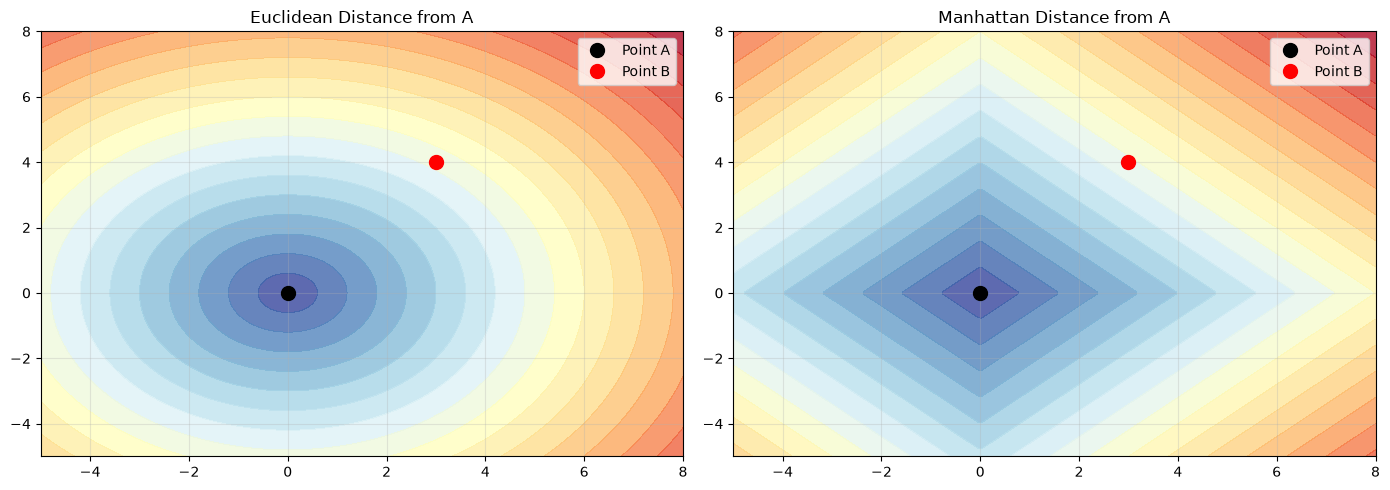

Euclidean distance A-B: 5.00
Manhattan distance A-B: 7.00


In [2]:
# Visualize distance metrics
point_a = np.array([0, 0])
point_b = np.array([3, 4])

# Create grid of points
x = np.linspace(-5, 8, 200)
y = np.linspace(-5, 8, 200)
X_grid, Y_grid = np.meshgrid(x, y)

# Distance from point_a
euclidean = np.sqrt((X_grid - point_a[0])**2 + (Y_grid - point_a[1])**2)
manhattan = np.abs(X_grid - point_a[0]) + np.abs(Y_grid - point_a[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dist, title in zip(axes, [euclidean, manhattan], ['Euclidean', 'Manhattan']):
    ax.contourf(X_grid, Y_grid, dist, levels=20, cmap='RdYlBu_r', alpha=0.8)
    ax.plot(*point_a, 'ko', markersize=10, label='Point A')
    ax.plot(*point_b, 'ro', markersize=10, label='Point B')
    ax.set_title(f'{title} Distance from A')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distance_metrics.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Euclidean distance A-B: {np.linalg.norm(point_a - point_b):.2f}")
print(f"Manhattan distance A-B: {np.sum(np.abs(point_a - point_b)):.2f}")

## 7. KNN from Scratch

In [3]:
class KNNClassifierScratch:
    """K-Nearest Neighbors from scratch."""
    
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def _predict_one(self, x):
        # Compute distances to all training points
        distances = np.array([self._euclidean_distance(x, x_train) for x_train in self.X_train])
        
        # Get k nearest indices
        k_indices = np.argsort(distances)[:self.k]
        
        # Get labels of k nearest
        k_labels = self.y_train[k_indices]
        
        # Majority vote
        values, counts = np.unique(k_labels, return_counts=True)
        return values[np.argmax(counts)]
    
    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("KNNClassifierScratch defined.")

KNNClassifierScratch defined.


In [4]:
# Load Iris dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Scale features (critical for KNN!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train from-scratch
knn_scratch = KNNClassifierScratch(k=5)
knn_scratch.fit(X_train_s, y_train)

# Compare with sklearn
knn_sklearn = KNeighborsClassifier(n_neighbors=5)
knn_sklearn.fit(X_train_s, y_train)

print("=== Comparison ===")
print(f"From Scratch: Train={knn_scratch.score(X_train_s, y_train):.4f}, Test={knn_scratch.score(X_test_s, y_test):.4f}")
print(f"Sklearn:      Train={knn_sklearn.score(X_train_s, y_train):.4f}, Test={knn_sklearn.score(X_test_s, y_test):.4f}")

=== Comparison ===


From Scratch: Train=0.9583, Test=1.0000
Sklearn:      Train=0.9583, Test=1.0000


## 8. Effect of K

- Small k (1-3): low bias, high variance (overfitting)
- Large k (10+): high bias, high underfitting
- Optimal k: balance between the two

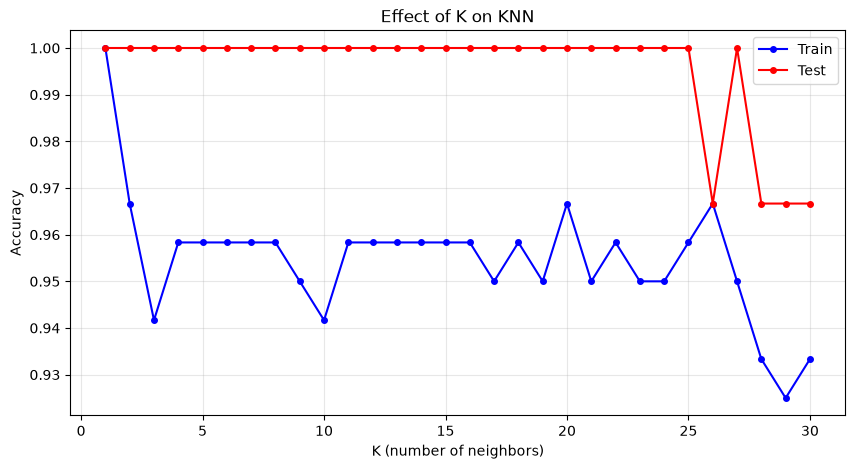

Best k=1: test accuracy=1.0000


In [5]:
# Effect of k on accuracy
k_range = range(1, 31)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    train_scores.append(knn.score(X_train_s, y_train))
    test_scores.append(knn.score(X_test_s, y_test))

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), train_scores, 'b-o', label='Train', markersize=4)
plt.plot(list(k_range), test_scores, 'r-o', label='Test', markersize=4)
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of K on KNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_effect.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Best k={list(k_range)[np.argmax(test_scores)]}: test accuracy={max(test_scores):.4f}")

## 9. Why Scaling Matters

KNN uses distance. If one feature has range 0-1000 and another 0-1, the large-range feature dominates.

In [6]:
# Without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)  # Raw features
acc_no_scale = knn_no_scale.score(X_test, y_test)

# With scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)  # Scaled features
acc_scaled = knn_scaled.score(X_test_s, y_test)

print(f"Without scaling: {acc_no_scale:.4f}")
print(f"With scaling:    {acc_scaled:.4f}")
print(f"Scaling improves accuracy by {acc_scaled - acc_no_scale:.4f}")

Without scaling: 1.0000
With scaling:    1.0000
Scaling improves accuracy by 0.0000


## 10. Common Mistakes

1. **Not scaling features** — distances are meaningless without scaling
2. **Using too small k** — overfits to noise
3. **Using too large k** — underfits, ignores local structure
4. **Not handling categorical features** — KNN needs numeric features
5. **High-dimensional data** — curse of dimensionality makes all points equidistant

## 11. Coding Exercises

### Exercise 1: Weighted KNN
Implement weighted KNN where closer neighbors have more vote weight.

### Exercise 2: Distance Metrics
Compare Euclidean vs Manhattan distance on the Iris dataset.

In [7]:
# EXERCISE 1: Weighted KNN
print("Exercise: Implement weighted KNN (weight = 1/distance).")

Exercise: Implement weighted KNN (weight = 1/distance).


In [8]:
# EXERCISE 2: Distance comparison
print("Exercise: Compare Euclidean vs Manhattan on Iris.")

Exercise: Compare Euclidean vs Manhattan on Iris.


## 12. Closed-Book Recall

1. What is the time complexity of KNN prediction?
2. Why must you scale features for KNN?
3. What happens when k equals the number of training samples?
4. What is the curse of dimensionality?

## 13. Teach-Back Questions

Explain to another person:
- Why KNN is called "lazy learning."
- How scaling affects distance calculations.
- When KNN fails (high dimensions, large datasets).

## 14. Summary

KNN classifies by majority vote of k nearest neighbors. Simple but effective for small, low-dimensional datasets. Critical: scale features, choose k wisely. Fails with high dimensions (curse of dimensionality) and large datasets (slow prediction).

## 15. Further Experiment

1. Implement KD-Tree for faster KNN prediction.
2. Compare KNN with logistic regression on a complex dataset.
3. Test KNN on the MNIST digits dataset. How does it perform?

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```